<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/linea_espera_2_servidores_ross.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Línea de espera con 2 servidores


El modelo que se usa como prueba es un sistema \(M/M/2\):

- Las llegadas siguen un proceso Poisson con tasa \(\lambda\).
- Los tiempos entre llegadas son exponenciales con parámetro \(\lambda\).
- Hay dos servidores.
- Cada servidor tiene tiempos de servicio exponenciales con parámetro \(\mu\).
- La disciplina de atención es FIFO: primero en llegar, primero en ser atendido.
- Si un cliente llega y hay un servidor libre, entra directamente a servicio.
- Si ambos servidores están ocupados, el cliente se forma en la cola.

Como prueba se usan:

$$\lambda = 4, \qquad \mu = 6$$

Aquí $\mu = 6$ es la tasa de servicio de **cada servidor**.



## 1. Librerías


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque



## 2. Parámetros del sistema
Para este sistema:
$$\lambda = 4$$
y

$$\mu = 6$$

Como hay dos servidores, la condición de estabilidad es:
$$\lambda < 2\mu$$

o equivalentemente:
$$\rho = \frac{\lambda}{2\mu} < 1$$


In [2]:
lambd = 4       # tasa de llegada
mu = 6          # tasa de servicio de cada servidor
c = 2           # número de servidores

# Parámetros de simulación
T = 10_000      # tiempo hasta el cual se aceptan llegadas
semilla = 123   # semilla para reproducibilidad

# Verificación de estabilidad
if lambd >= c * mu:
    raise ValueError("El sistema M/M/2 no es estable porque lambda debe ser menor que 2*mu.")

print("lambda =", lambd)
print("mu =", mu)
print("número de servidores =", c)
print("rho = lambda/(2*mu) =", lambd/(c*mu))


lambda = 4
mu = 6
número de servidores = 2
rho = lambda/(2*mu) = 0.3333333333333333



## 3. Solución analítica del sistema \(M/M/2\)

Para comparar contra la simulación, usamos las fórmulas analíticas de un sistema $M/M/c$ con $c=2$

Definimos:
$$a = \frac{\lambda}{\mu}$$
$$\rho = \frac{\lambda}{c\mu}$$

Para $c=2$, la probabilidad de que el sistema esté vacío es:
$$P_0 =
\left[
\sum_{n=0}^{c-1} \frac{a^n}{n!}
+
\frac{a^c}{c!}\frac{1}{1-\rho}
\right]^{-1}$$

El número promedio de clientes en fila es:
$$L_q =
P_0
\frac{a^c \rho}{c!(1-\rho)^2}$$

Luego:
$$W_q = \frac{L_q}{\lambda}$$
$$W = W_q + \frac{1}{\mu}$$
$$L = \lambda W$$

Además, la probabilidad de que un cliente tenga que esperar es:
$$
P(\text{esperar}) =
P_0
\frac{a^c}{c!(1-\rho)}$$


In [3]:

def solucion_analitica_mmc(lambd, mu, c):
    from math import factorial

    a = lambd / mu
    rho = lambd / (c * mu)

    suma = sum((a**n) / factorial(n) for n in range(c))
    termino_final = (a**c / factorial(c)) * (1 / (1 - rho))

    P0 = 1 / (suma + termino_final)

    Lq = P0 * (a**c * rho) / (factorial(c) * (1 - rho)**2)
    Wq = Lq / lambd
    W = Wq + 1 / mu
    L = lambd * W

    prob_esperar = P0 * (a**c / factorial(c)) * (1 / (1 - rho))

    return {
        "rho": rho,
        "P0": P0,
        "P_esperar": prob_esperar,
        "L": L,
        "Lq": Lq,
        "W": W,
        "Wq": Wq
    }

analitica = solucion_analitica_mmc(lambd, mu, c)

tabla_analitica = pd.DataFrame({
    "Medida": ["rho", "P0", "P_esperar", "L", "Lq", "W", "Wq"],
    "Descripción": [
        "Utilización promedio de cada servidor",
        "Probabilidad de sistema vacío",
        "Probabilidad de que un cliente espere",
        "Clientes promedio en el sistema",
        "Clientes promedio en la fila",
        "Tiempo promedio en el sistema",
        "Tiempo promedio en la fila"
    ],
    "Valor analítico": [
        analitica["rho"],
        analitica["P0"],
        analitica["P_esperar"],
        analitica["L"],
        analitica["Lq"],
        analitica["W"],
        analitica["Wq"]
    ]
})

tabla_analitica


,Medida,Descripción,Valor analítico
0,rho,Utilización promedio de cada servidor,0.333333
1,P0,Probabilidad de sistema vacío,0.500000
2,P_esperar,Probabilidad de que un cliente espere,0.166667
3,L,Clientes promedio en el sistema,0.750000
4,Lq,Clientes promedio en la fila,0.083333
5,W,Tiempo promedio en el sistema,0.187500
6,Wq,Tiempo promedio en la fila,0.020833



## 4. Variables del seudocódigo de Ross para 2 servidores

Para dos servidores se conserva la misma idea de eventos discretos, pero ahora hay dos tiempos posibles de salida.

Usamos:

- $t$: tiempo actual.
- $N_A$: número de llegadas hasta el instante \(t\).
- $N_D$: número de salidas hasta el instante \(t\).
- $n$: número de clientes dentro del sistema.
- $t_A$: tiempo de la siguiente llegada.
- $t_{D1}$: tiempo de salida programada del servidor 1.
- $t_{D2}$: tiempo de salida programada del servidor 2.
- $A(i)$: tiempo de llegada del cliente \(i\).
- $D(i)$: tiempo de salida del cliente \(i\).

La lista de eventos es:
$$LE = (t_A, t_{D1}, t_{D2})$$

En cada paso se toma el evento con menor tiempo.



## 5. Función de simulación para dos servidores

La función siguiente implementa los casos principales del seudocódigo:

### Caso 1

Si la siguiente llegada ocurre antes que cualquier salida y antes de \(T\), entra un nuevo cliente.

Si hay servidor libre, inicia servicio inmediatamente. Si no, entra a la cola.

### Caso 2

Si la siguiente salida ocurre antes que la llegada y antes de \(T\), sale un cliente.

Si hay alguien esperando, pasa al servidor que acaba de liberarse.

### Caso 3

Si ya se pasó el tiempo \(T\), ya no se aceptan nuevas llegadas, pero se siguen atendiendo los clientes que quedaron dentro del sistema.

### Caso 4

Si ya se pasó el tiempo \(T\) y no hay clientes en el sistema, termina la simulación.


In [4]:

def simular_mm2_ross(lambd, mu, T, semilla=None):

    rng = np.random.default_rng(semilla)

    t = 0.0
    NA = 0
    ND = 0
    n = 0

    A = []      # Tiempos de llegada, salida, inicio de servicio y servicio
    D = []
    inicio_servicio = []
    S = []


    cola = deque()

    servidor_cliente = [None, None]

    # tD[j] es el tiempo de salida programada del servidor j
    tD = [np.inf, np.inf]

    # Primera llegada
    tA = rng.exponential(scale=1/lambd)

    # Áreas para promedios temporales
    area_n = 0.0      # área bajo n(t)
    area_q = 0.0      # área bajo q(t)
    area_ocupados = 0.0  # área bajo número de servidores ocupados

    tiempo_anterior = 0.0

    # Para graficar n(t)
    tiempos_grafica = [0.0]
    n_grafica = [0]

    # Para registrar eventos
    eventos = []

    while True:

        # Mínimo tiempo de salida entre los dos servidores
        min_tD = min(tD)
        servidor_salida = int(np.argmin(tD))

        # CASO 1:
        # tA <= min(tD1, tD2) y tA <= T
        # Ocurre una llegada antes que cualquier salida y antes de T.

        if tA <= min_tD and tA <= T:

            nuevo_t = tA

            # Actualizar áreas desde el evento anterior
            area_n += n * (nuevo_t - tiempo_anterior)
            area_q += max(n - 2, 0) * (nuevo_t - tiempo_anterior)
            area_ocupados += min(n, 2) * (nuevo_t - tiempo_anterior)
            tiempo_anterior = nuevo_t

            t = nuevo_t
            NA += 1
            n += 1

            # Registrar al cliente nuevo
            A.append(t)
            D.append(np.nan)
            inicio_servicio.append(np.nan)
            S.append(np.nan)

            cliente = NA - 1

            # Revisar si hay algún servidor libre
            if servidor_cliente[0] is None:
                servidor_libre = 0
            elif servidor_cliente[1] is None:
                servidor_libre = 1
            else:
                servidor_libre = None

            if servidor_libre is not None:
                # El cliente entra directamente a servicio
                servidor_cliente[servidor_libre] = cliente
                inicio_servicio[cliente] = t

                tiempo_servicio = rng.exponential(scale=1/mu)
                S[cliente] = tiempo_servicio

                tD[servidor_libre] = t + tiempo_servicio
            else:
                # Ambos servidores están ocupados, el cliente se forma
                cola.append(cliente)

            # Generar siguiente llegada
            tA = t + rng.exponential(scale=1/lambd)

            eventos.append([
                t, "Llegada", NA, ND, n,
                len(cola),
                servidor_cliente[0],
                servidor_cliente[1],
                tA, tD[0], tD[1]
            ])

            tiempos_grafica.append(t)
            n_grafica.append(n)

        # CASO 2:
        # min(tD1, tD2) < tA y min(tD1, tD2) <= T
        # Ocurre una salida antes de la siguiente llegada y antes de T.

        elif min_tD < tA and min_tD <= T:

            nuevo_t = min_tD

            area_n += n * (nuevo_t - tiempo_anterior)
            area_q += max(n - 2, 0) * (nuevo_t - tiempo_anterior)
            area_ocupados += min(n, 2) * (nuevo_t - tiempo_anterior)
            tiempo_anterior = nuevo_t

            t = nuevo_t
            n -= 1
            ND += 1

            # Cliente que sale del servidor correspondiente
            cliente_sale = servidor_cliente[servidor_salida]
            D[cliente_sale] = t

            # El servidor queda libre momentáneamente
            servidor_cliente[servidor_salida] = None

            # Si hay clientes esperando, el siguiente pasa al servidor liberado
            if len(cola) > 0:
                siguiente_cliente = cola.popleft()
                servidor_cliente[servidor_salida] = siguiente_cliente
                inicio_servicio[siguiente_cliente] = t

                tiempo_servicio = rng.exponential(scale=1/mu)
                S[siguiente_cliente] = tiempo_servicio

                tD[servidor_salida] = t + tiempo_servicio
            else:
                tD[servidor_salida] = np.inf

            eventos.append([
                t, "Salida antes de T", NA, ND, n,
                len(cola),
                servidor_cliente[0],
                servidor_cliente[1],
                tA, tD[0], tD[1]
            ])

            tiempos_grafica.append(t)
            n_grafica.append(n)

        # CASO 3:
        # min(tA, tD1, tD2) > T y n > 0
        # Ya no se aceptan llegadas, pero quedan clientes por atender.
        elif min(tA, min_tD) > T and n > 0:

            nuevo_t = min_tD

            area_n += n * (nuevo_t - tiempo_anterior)
            area_q += max(n - 2, 0) * (nuevo_t - tiempo_anterior)
            area_ocupados += min(n, 2) * (nuevo_t - tiempo_anterior)
            tiempo_anterior = nuevo_t

            t = nuevo_t
            n -= 1
            ND += 1

            # Después de T ya no hay llegadas
            tA = np.inf

            cliente_sale = servidor_cliente[servidor_salida]
            D[cliente_sale] = t

            servidor_cliente[servidor_salida] = None

            if len(cola) > 0:
                siguiente_cliente = cola.popleft()
                servidor_cliente[servidor_salida] = siguiente_cliente
                inicio_servicio[siguiente_cliente] = t

                tiempo_servicio = rng.exponential(scale=1/mu)
                S[siguiente_cliente] = tiempo_servicio

                tD[servidor_salida] = t + tiempo_servicio
            else:
                tD[servidor_salida] = np.inf

            eventos.append([
                t, "Salida después de T", NA, ND, n,
                len(cola),
                servidor_cliente[0],
                servidor_cliente[1],
                tA, tD[0], tD[1]
            ])

            tiempos_grafica.append(t)
            n_grafica.append(n)
        # CASO 4:
        # Ya no habrá llegadas y el sistema está vacío.
        # Termina la simulación.

        else:
            Tp = max(t - T, 0)
            break

    # Convertir listas a arreglos
    A = np.array(A)
    D = np.array(D)
    inicio_servicio = np.array(inicio_servicio)
    S = np.array(S)

    tiempo_final = t

    # Medidas por cliente
    tiempo_sistema = D - A
    tiempo_fila = inicio_servicio - A

    # Medidas por promedios temporales
    L_sim = area_n / tiempo_final
    Lq_sim = area_q / tiempo_final

    # Medidas por promedios de clientes
    W_sim = np.mean(tiempo_sistema)
    Wq_sim = np.mean(tiempo_fila)

    # Utilización promedio por servidor
    rho_sim = area_ocupados / (2 * tiempo_final)

    # Probabilidad simulada de esperar
    prob_esperar_sim = np.mean(tiempo_fila > 0)

    return {
        "A": A,
        "D": D,
        "inicio_servicio": inicio_servicio,
        "S": S,
        "tiempo_sistema": tiempo_sistema,
        "tiempo_fila": tiempo_fila,
        "NA": NA,
        "ND": ND,
        "Tp": Tp,
        "tiempo_final": tiempo_final,
        "L": L_sim,
        "Lq": Lq_sim,
        "W": W_sim,
        "Wq": Wq_sim,
        "rho": rho_sim,
        "P_esperar": prob_esperar_sim,
        "eventos": eventos,
        "tiempos_grafica": tiempos_grafica,
        "n_grafica": n_grafica
    }



## 6. Ejecutar una simulación


In [5]:

resultado = simular_mm2_ross(lambd, mu, T, semilla=semilla)

print("Número total de llegadas NA:", resultado["NA"])
print("Número total de salidas ND:", resultado["ND"])
print("Tiempo final de simulación:", resultado["tiempo_final"])
print("Tiempo posterior a T para que salga el último cliente, Tp:", resultado["Tp"])


Número total de llegadas NA: 39964
Número total de salidas ND: 39964
Tiempo final de simulación: 10000.032682194997
Tiempo posterior a T para que salga el último cliente, Tp: 0.03268219499659608



## 7. Tabla de los primeros clientes

Para cada cliente se muestra:

- $A(i)$: tiempo de llegada.
- Inicio de servicio.
- $D(i)$: tiempo de salida.
- Tiempo en fila.
- Tiempo total en el sistema.


In [6]:

tabla_clientes = pd.DataFrame({
    "cliente": np.arange(1, len(resultado["A"]) + 1),
    "A(i) llegada": resultado["A"],
    "inicio servicio": resultado["inicio_servicio"],
    "D(i) salida": resultado["D"],
    "tiempo en fila": resultado["tiempo_fila"],
    "tiempo en sistema": resultado["tiempo_sistema"]
})

tabla_clientes.head(10)


,cliente,A(i) llegada,inicio servicio,D(i) salida,tiempo en fila,tiempo en sistema
0,1,0.149243,0.149243,0.168748,0.0,0.019505
1,2,0.212192,0.212192,0.263519,0.0,0.051328
2,3,0.235142,0.235142,0.627079,0.0,0.391937
3,4,1.307260,1.307260,1.333032,0.0,0.025772
4,5,1.431689,1.431689,1.569404,0.0,0.137714
5,6,1.654031,1.654031,1.714821,0.0,0.060790
6,7,2.061613,2.061613,2.139652,0.0,0.078039
7,8,2.251556,2.251556,2.386414,0.0,0.134858
8,9,2.549365,2.549365,2.573740,0.0,0.024375
9,10,2.675354,2.675354,2.721507,0.0,0.046153



## 8. Tabla de eventos

Esta tabla permite ver la evolución del sistema evento por evento.

Se muestran las variables principales:

- $t$
- tipo de evento
- $N_A$
- $N_D$
- $n$
- longitud de la cola
- cliente en servidor 1
- cliente en servidor 2
- $t_A$
- $t_{D1}$
- $t_{D2}$


In [7]:

tabla_eventos = pd.DataFrame(
    resultado["eventos"],
    columns=[
        "t",
        "evento",
        "NA",
        "ND",
        "n",
        "longitud cola",
        "cliente serv 1",
        "cliente serv 2",
        "tA",
        "tD1",
        "tD2"
    ]
)

tabla_eventos.head(20)


,t,evento,NA,ND,n,longitud cola,cliente serv 1,cliente serv 2,tA,tD1,tD2
0,0.149243,Llegada,1,0,1,0,0.0,NaN,0.212192,0.168748,inf
1,0.168748,Salida antes de T,1,1,0,0,NaN,NaN,0.212192,inf,inf
2,0.212192,Llegada,2,1,1,0,1.0,NaN,0.235142,0.263519,inf
3,0.235142,Llegada,3,1,2,0,1.0,2.0,1.307260,0.263519,0.627079
4,0.263519,Salida antes de T,3,2,1,0,NaN,2.0,1.307260,inf,0.627079
5,0.627079,Salida antes de T,3,3,0,0,NaN,NaN,1.307260,inf,inf
6,1.307260,Llegada,4,3,1,0,3.0,NaN,1.431689,1.333032,inf
7,1.333032,Salida antes de T,4,4,0,0,NaN,NaN,1.431689,inf,inf
8,1.431689,Llegada,5,4,1,0,4.0,NaN,1.654031,1.569404,inf
9,1.569404,Salida antes de T,5,5,0,0,NaN,NaN,1.654031,inf,inf



## 9. Gráfica de $n(t)$

La gráfica muestra el número de clientes dentro del sistema.

Para que se vea con claridad, solamente se grafica una ventana inicial.


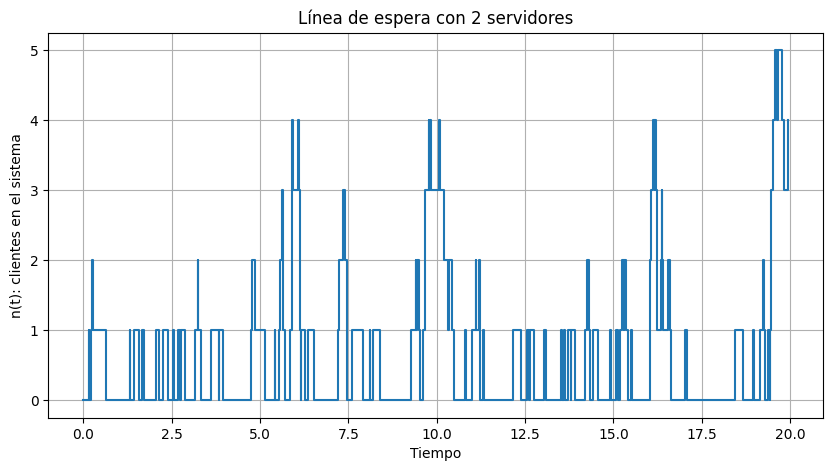

In [8]:

limite_grafica = 20

tiempos = np.array(resultado["tiempos_grafica"])
valores_n = np.array(resultado["n_grafica"])

mascara = tiempos <= limite_grafica

plt.figure(figsize=(10, 5))
plt.step(tiempos[mascara], valores_n[mascara], where="post")
plt.xlabel("Tiempo")
plt.ylabel("n(t): clientes en el sistema")
plt.title("Línea de espera con 2 servidores")
plt.grid(True)
plt.show()



## 10. Comparación analítica contra simulación

Ahora comparamos las medidas teóricas del sistema \(M/M/2\) contra las estimaciones obtenidas por simulación.


In [9]:

simulacion = {
    "rho": resultado["rho"],
    "P_esperar": resultado["P_esperar"],
    "L": resultado["L"],
    "Lq": resultado["Lq"],
    "W": resultado["W"],
    "Wq": resultado["Wq"]
}

comparacion = pd.DataFrame({
    "Medida": ["rho", "P_esperar", "L", "Lq", "W", "Wq"],
    "Valor analítico": [
        analitica["rho"],
        analitica["P_esperar"],
        analitica["L"],
        analitica["Lq"],
        analitica["W"],
        analitica["Wq"]
    ],
    "Valor por simulación": [
        simulacion["rho"],
        simulacion["P_esperar"],
        simulacion["L"],
        simulacion["Lq"],
        simulacion["W"],
        simulacion["Wq"]
    ]
})

comparacion["Error absoluto"] = abs(
    comparacion["Valor por simulación"] - comparacion["Valor analítico"]
)

comparacion["Error relativo (%)"] = (
    100 * comparacion["Error absoluto"] / comparacion["Valor analítico"]
)

comparacion


,Medida,Valor analítico,Valor por simulación,Error absoluto,Error relativo (%)
0,rho,0.333333,0.333220,0.000113,0.033913
1,P_esperar,0.166667,0.167976,0.001310,0.785707
2,L,0.750000,0.749943,0.000057,0.007560
3,Lq,0.083333,0.083503,0.000169,0.203272
4,W,0.187500,0.187655,0.000155,0.082842
5,Wq,0.020833,0.020895,0.000061,0.293864



## 11. Muchas réplicas

Una sola simulación tiene variabilidad aleatoria. Por eso repetimos el experimento varias veces y promediamos.

Al aumentar \(T\) y el número de réplicas, los valores simulados deben acercarse a los valores analíticos.


In [10]:

R = 100

resultados_replicas = []

for r in range(R):
    res = simular_mm2_ross(lambd, mu, T, semilla=1000 + r)

    resultados_replicas.append({
        "replica": r + 1,
        "rho": res["rho"],
        "P_esperar": res["P_esperar"],
        "L": res["L"],
        "Lq": res["Lq"],
        "W": res["W"],
        "Wq": res["Wq"],
        "NA": res["NA"],
        "Tp": res["Tp"]
    })

df_replicas = pd.DataFrame(resultados_replicas)

df_replicas.head()


,replica,rho,P_esperar,L,Lq,W,Wq,NA,Tp
0,1,0.334050,0.165375,0.750283,0.082183,0.186376,0.020415,40254,0.000000
1,2,0.333554,0.168373,0.749929,0.082821,0.187675,0.020726,39959,0.010234
2,3,0.332206,0.162457,0.743686,0.079274,0.185413,0.019764,40109,0.000000
3,4,0.334634,0.168396,0.754920,0.085653,0.188694,0.021409,40007,0.000000
4,5,0.336602,0.167676,0.758849,0.085645,0.189119,0.021344,40125,0.000000


In [11]:

promedios_simulacion = df_replicas[["rho", "P_esperar", "L", "Lq", "W", "Wq"]].mean()

comparacion_replicas = pd.DataFrame({
    "Medida": ["rho", "P_esperar", "L", "Lq", "W", "Wq"],
    "Valor analítico": [
        analitica["rho"],
        analitica["P_esperar"],
        analitica["L"],
        analitica["Lq"],
        analitica["W"],
        analitica["Wq"]
    ],
    "Promedio por simulación": [
        promedios_simulacion["rho"],
        promedios_simulacion["P_esperar"],
        promedios_simulacion["L"],
        promedios_simulacion["Lq"],
        promedios_simulacion["W"],
        promedios_simulacion["Wq"]
    ]
})

comparacion_replicas["Error absoluto"] = abs(
    comparacion_replicas["Promedio por simulación"] - comparacion_replicas["Valor analítico"]
)

comparacion_replicas["Error relativo (%)"] = (
    100 * comparacion_replicas["Error absoluto"] / comparacion_replicas["Valor analítico"]
)

comparacion_replicas


,Medida,Valor analítico,Promedio por simulación,Error absoluto,Error relativo (%)
0,rho,0.333333,0.333525,0.000191,0.057430
1,P_esperar,0.166667,0.166668,0.000001,0.000682
2,L,0.750000,0.750297,0.000297,0.039663
3,Lq,0.083333,0.083248,0.000085,0.102477
4,W,0.187500,0.187583,0.000083,0.044109
5,Wq,0.020833,0.020812,0.000022,0.104643



## 12. Gráfica comparativa


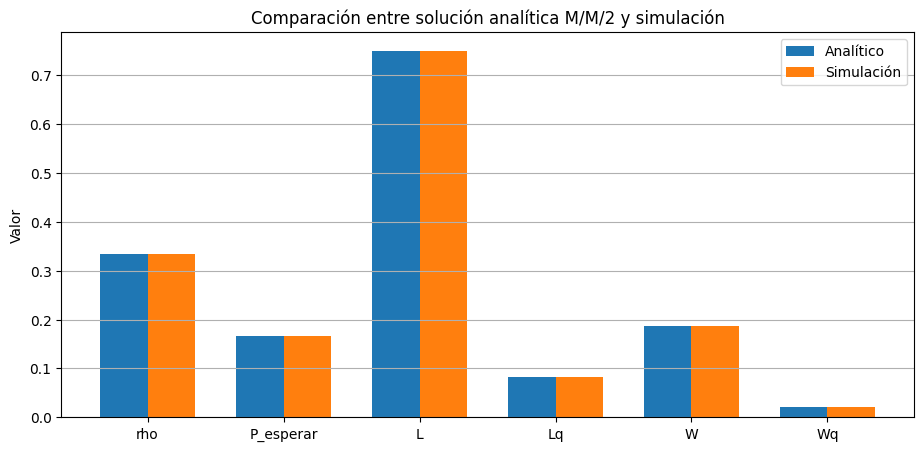

In [12]:

medidas = ["rho", "P_esperar", "L", "Lq", "W", "Wq"]
x = np.arange(len(medidas))
ancho = 0.35

valores_analiticos = comparacion_replicas["Valor analítico"].values
valores_simulados = comparacion_replicas["Promedio por simulación"].values

plt.figure(figsize=(11, 5))
plt.bar(x - ancho/2, valores_analiticos, width=ancho, label="Analítico")
plt.bar(x + ancho/2, valores_simulados, width=ancho, label="Simulación")
plt.xticks(x, medidas)
plt.ylabel("Valor")
plt.title("Comparación entre solución analítica M/M/2 y simulación")
plt.legend()
plt.grid(axis="y")
plt.show()



## 13. Conclusión

Para $\lambda = 4$, $\mu = 6$ y $c=2$, se tiene:

$$\rho = \frac{\lambda}{2\mu}
= \frac{4}{12}
= 0.3333$$

Como $\rho < 1$, el sistema es estable.

Los valores analíticos aproximados son:
$$P_0 = 0.5$$
$$P(\text{esperar}) = 0.1667$$
$$L = 0.75$$
$$L_q = 0.0833$$
$$W = 0.1875$$
$$W_q = 0.0208$$

La simulación por eventos discretos reproduce el comportamiento del sistema. Como se usan números aleatorios, los valores simulados no tienen que coincidir exactamente con los analíticos, pero deben ser cercanos. Al aumentar el tiempo de simulación $T$ y el número de réplicas $R$, la aproximación mejora.
